# Full Exploratory Data Analysis of MultiWOZ 2.2

## Data Loading & Preparation

### Download the dataset

In [1]:
# Shallow clone keeps only the latest commit (no full history)
!git clone --depth 1 https://github.com/budzianowski/multiwoz.git /content/multiwoz

Cloning into '/content/multiwoz'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 66 (delta 22), reused 23 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 54.66 MiB | 9.56 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Updating files: 100% (61/61), done.


In [2]:
# Total size of the cloned repo (366MB)
!du -sh /content/multiwoz

366M	/content/multiwoz


In [3]:
# Verify the MultiWOZ 2.2 folder is present
!ls /content/multiwoz/data/MultiWOZ_2.2

convert_to_multiwoz_format.py  dialog_acts.json  requirements.txt  test
dev			       README.md	 schema.json	   train


### Imports and data paths

In [4]:
import json
import shutil
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting defaults (set once, apply to every later figure)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# List for saving all figures
saved_figures = []

In [5]:
# Data paths (all relative to the cloned repo)
REPO_DIR = Path("/content/multiwoz")
MWZ22_DIR = REPO_DIR / "data" / "MultiWOZ_2.2"
TRAIN_DIR = MWZ22_DIR / "train"
DEV_DIR = MWZ22_DIR / "dev"
TEST_DIR = MWZ22_DIR / "test"
DIALOG_ACTS_FILE = MWZ22_DIR / "dialog_acts.json"
SCHEMA_FILE = MWZ22_DIR / "schema.json"
DB_DIR = REPO_DIR / "db"

FIG_DIR = Path("/content/figures")
FIG_DIR.mkdir(exist_ok=True)

### Load all splits into memory

In [6]:
# Check what is inside each split folder
for split_dir in [TRAIN_DIR, DEV_DIR, TEST_DIR]:
  files = sorted(split_dir.glob("dialogues_*.json"))
  print(f"{split_dir.name}: {len(files)} files -> {[f.name for f in files]}")

train: 17 files -> ['dialogues_001.json', 'dialogues_002.json', 'dialogues_003.json', 'dialogues_004.json', 'dialogues_005.json', 'dialogues_006.json', 'dialogues_007.json', 'dialogues_008.json', 'dialogues_009.json', 'dialogues_010.json', 'dialogues_011.json', 'dialogues_012.json', 'dialogues_013.json', 'dialogues_014.json', 'dialogues_015.json', 'dialogues_016.json', 'dialogues_017.json']
dev: 2 files -> ['dialogues_001.json', 'dialogues_002.json']
test: 2 files -> ['dialogues_001.json', 'dialogues_002.json']


In [7]:
def load_split(split_dir: Path) -> list[dict]:
  """
  Each split is split across several JSON files (parts). Load and merge them all.

  Args:
      split_dir: path to a split folder (e.g., TRAIN_DIR)
  Return:
      list of dialogue dicts from all shards
  """
  dialogues = []
  for json_file in sorted(split_dir.glob("dialogues_*.json")):
    with open(json_file, "r", encoding="utf-8") as f:
      dialogues.extend(json.load(f))
  return dialogues

In [8]:
train = load_split(TRAIN_DIR)
dev = load_split(DEV_DIR)
test = load_split(TEST_DIR)

In [9]:
print(f"train: {len(train)} dialogues")
print(f"dev: {len(dev)} dialogues")
print(f"test: {len(test)} dialogues")
print(f"total: {len(train) + len(dev) + len(test)} dialogues")

train: 8437 dialogues
dev: 1000 dialogues
test: 1000 dialogues
total: 10437 dialogues


MultiWOZ 2.2 is organised into 3 split folders (`train`, `dev`, `test`), each containing multiple JSON files. Train is split across 17 files (8437 dialogues), dev and test across 2 files each (1000 dialogues each). In total we have 10437 dialogues.

### Inspect a raw dialogue

In [10]:
d = train[0]
print(json.dumps(d, indent=2))

{
  "dialogue_id": "PMUL4398.json",
  "services": [
    "restaurant",
    "hotel"
  ],
  "turns": [
    {
      "frames": [
        {
          "actions": [],
          "service": "restaurant",
          "slots": [],
          "state": {
            "active_intent": "find_restaurant",
            "requested_slots": [],
            "slot_values": {
              "restaurant-area": [
                "centre"
              ],
              "restaurant-pricerange": [
                "expensive"
              ]
            }
          }
        },
        {
          "actions": [],
          "service": "taxi",
          "slots": [],
          "state": {
            "active_intent": "NONE",
            "requested_slots": [],
            "slot_values": {}
          }
        },
        {
          "actions": [],
          "service": "train",
          "slots": [],
          "state": {
            "active_intent": "NONE",
            "requested_slots": [],
            "slot_values": {}
       

In [11]:
# Show top-level keys, types, and example values by walking dialogue: turn -> frame -> state
d = train[0]

print("Top level keys")
print(f"type: {type(d).__name__}")
print(f"keys: {list(d.keys())}")
print(f"dialogue_id: {type(d['dialogue_id']).__name__} | {d['dialogue_id']}")
print(f"services: {type(d['services']).__name__} of {type(d['services'][0]).__name__} | length {len(d['services'])} | {d['services']}")
print(f"turns: {type(d['turns']).__name__} of {type(d['turns'][0]).__name__} | length {len(d['turns'])}")

print("\nFIRST TURN")
t = d["turns"][0]
print(f"keys: {list(t.keys())}")
print(f"speaker: {type(t['speaker']).__name__} | {t['speaker']}")
print(f"turn_id: {type(t['turn_id']).__name__} | {t['turn_id']}")
print(f"utterance: {type(t['utterance']).__name__} | {t['utterance']}")
print(f"frames: {type(t['frames']).__name__} of {type(t['frames'][0]).__name__} | length {len(t['frames'])}")

print("\nFIRST FRAME (of first turn)")
f = t["frames"][0]
print(f"keys: {list(f.keys())}")
print(f"service: {type(f['service']).__name__} | {f['service']}")
print(f"actions: {type(f['actions']).__name__} | length {len(f['actions'])}")
print(f"slots: {type(f['slots']).__name__} | length {len(f['slots'])}")
print(f"state: {type(f['state']).__name__} | keys {list(f['state'].keys())}")

print("\nSTATE (of first frame)")
s = f["state"]
print(f"active_intent: {type(s['active_intent']).__name__} | {s['active_intent']}")
print(f"requested_slots: {type(s['requested_slots']).__name__} | length {len(s['requested_slots'])} | {s['requested_slots']}")
print(f"slot_values: {type(s['slot_values']).__name__} | length {len(s['slot_values'])} | {s['slot_values']}")

Top level keys
type: dict
keys: ['dialogue_id', 'services', 'turns']
dialogue_id: str | PMUL4398.json
services: list of str | length 2 | ['restaurant', 'hotel']
turns: list of dict | length 12

FIRST TURN
keys: ['frames', 'speaker', 'turn_id', 'utterance']
speaker: str | USER
turn_id: str | 0
utterance: str | i need a place to dine in the center thats expensive
frames: list of dict | length 8

FIRST FRAME (of first turn)
keys: ['actions', 'service', 'slots', 'state']
service: str | restaurant
actions: list | length 0
slots: list | length 0
state: dict | keys ['active_intent', 'requested_slots', 'slot_values']

STATE (of first frame)
active_intent: str | find_restaurant
requested_slots: list | length 0 | []
slot_values: dict | length 2 | {'restaurant-area': ['centre'], 'restaurant-pricerange': ['expensive']}


In [12]:
# Same walk-through for a SYSTEM turn (turn 1 of the same dialogue)
t = d["turns"][1]

print(f"speaker: {t['speaker']}")
print(f"turn_id: {t['turn_id']}")
print(f"utterance: {t['utterance']}")
print(f"frames: {type(t['frames']).__name__} | length {len(t['frames'])} | {t['frames']}")

speaker: SYSTEM
turn_id: 1
utterance: I have several options for you; do you prefer African, Asian, or British food?
frames: list | length 0 | []


Each turn has four keys: `speaker` (`USER` or `SYSTEM`), `turn_id`, `utterance` (the raw text), and `frames`. A **user turn** has 8 frames (one per MultiWOZ domain: hotel, restaurant, taxi, train, attraction, bus, hospital, police), and each frame holds that domain's `service`, `actions`, `slots`, and a `state` dict with `active_intent`, `requested_slots`, and `slot_values`. If the user is not engaging with a given domain in this turn, that frame's `active_intent` is `NONE` and its `slot_values` is empty. A **system turn**, by contrast, has an **empty** `frames` list as the system side has no belief state, only an utterance. Dialog act annotations for both speakers live in a separate file (`dialog_acts.json`).


Each dialogue is a dict with three top-level keys: `dialogue_id` (str, e.g. `PMUL4398.json`), `services` (list of the domains involved, e.g. `['restaurant', 'hotel']`), and `turns` (list of turn dicts).

Each turn has four keys: `speaker` (`USER` or `SYSTEM`), `turn_id`, `utterance` (the raw text), and `frames`. A **user turn** has 8 frames (one per MultiWOZ domain: hotel, restaurant, taxi, train, attraction, bus, hospital, police), and each frame holds that domain's `service`, `actions`, `slots`, and a `state` dict with `active_intent`, `requested_slots`, and `slot_values`. `slot_values` are the constraints the user has provided so far (e.g. `restaurant-area = centre`) and `requested_slots` are the pieces of information the user is asking the system to provide (e.g. `restaurant-phone`). If the user is not engaging with a given domain in this turn, that frame's `active_intent` is `NONE` and its `slot_values` is empty.

A **system turn** has the same four keys (`speaker`, `turn_id`, `utterance`, `frames`), but its `frames` list only contains entries when the system recommends or mentions a specific entity. In that case `frames[i].slots` carries character-level spans pointing to the mentioned value (e.g. `"Bedouin"` at characters 31-38 of the utterance, tagged as `restaurant-name`). The system side has no belief state, so `state`, `active_intent`, `requested_slots`, and `slot_values` never appear in system frames. Dialog act annotations for both speakers live in a separate file (`dialog_acts.json`), which we attach in the next cell.

### Attach dialog acts to every turn

In [13]:
def attach_dialog_acts(dialogues: list[dict], acts: dict) -> None:
  """
  Add a 'dialog_act' key to every turn, in place.

  Args:
      dialogues: list of dialogue dicts from load_split()
      acts: dict loaded from dialog_acts.json
  Return:
      None (modifies dialogues in place)
  """
  for d in dialogues:
    per_turn = acts.get(d["dialogue_id"], {})
    for turn in d["turns"]:
      entry = per_turn.get(str(turn["turn_id"]), {})
      turn["dialog_act"] = entry.get("dialog_act", {})

In [14]:
# Dialog acts live in a separate file keyed by dialogue_id -> turn_id. We merge them into each turn so later cells can read turn["dialog_act"] directly
with open(DIALOG_ACTS_FILE, "r", encoding="utf-8") as f:
  dialog_acts = json.load(f)

attach_dialog_acts(train, dialog_acts)
attach_dialog_acts(dev, dialog_acts)
attach_dialog_acts(test, dialog_acts)

In [15]:
# Verify: first user turn of the first train dialogue now has a dialog_act
t = train[0]["turns"][0]
print(f"turn_id: {t['turn_id']}")
print(f"speaker: {t['speaker']}")
print(f"utterance: {t['utterance']}")
print(f"dialog_act: {t['dialog_act']}")

turn_id: 0
speaker: USER
utterance: i need a place to dine in the center thats expensive
dialog_act: {'Restaurant-Inform': [['area', 'centre'], ['pricerange', 'expensive']]}


## Dataset Overview

### Split sizes

In [16]:
# Count dialogues and turns (user vs system) per split
rows = []
for split_name, dialogues in [("train", train), ("dev", dev), ("test", test)]:
  n_dialogues = len(dialogues)
  n_user = sum(1 for d in dialogues for t in d["turns"] if t["speaker"] == "USER")
  n_system = sum(1 for d in dialogues for t in d["turns"] if t["speaker"] == "SYSTEM")
  rows.append({
      "split": split_name,
      "dialogues": n_dialogues,
      "user turns": n_user,
      "system turns": n_system,
      "total turns": n_user + n_system,
  })

df_splits = pd.DataFrame(rows)
df_splits.loc["total"] = ["total"] + df_splits[df_splits.columns[1:]].sum().tolist()
df_splits

,split,dialogues,user turns,system turns,total turns
0,train,8437,56776,56776,113552
1,dev,1000,7374,7374,14748
2,test,1000,7372,7372,14744
total,total,10437,71522,71522,143044


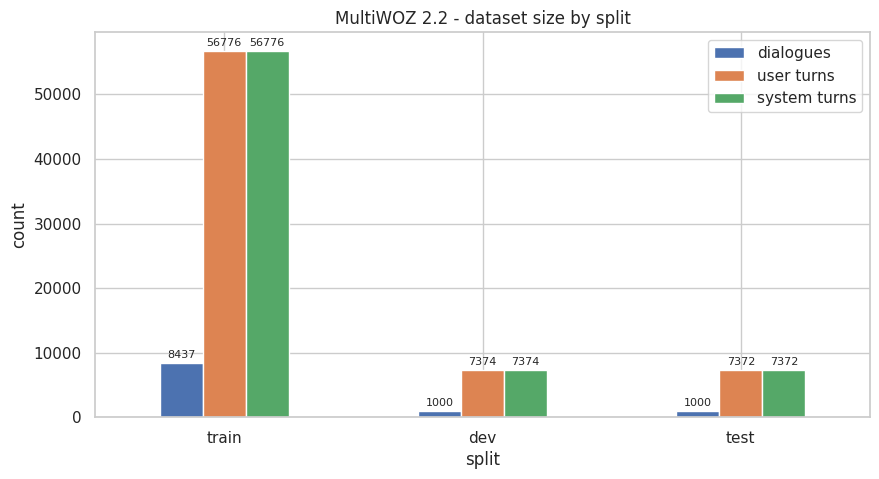

In [17]:
# Grouped bar chart of the split sizes (excluding the 'total' row)
df_plot = df_splits.drop(index="total").set_index("split")

ax = df_plot[["dialogues", "user turns", "system turns"]].plot(kind="bar", rot=0)
plt.ylabel("count")
plt.title("MultiWOZ 2.2 - dataset size by split")
plt.legend(loc="upper right")

# Annotate each bar with its numeric height
for container in ax.containers:
  ax.bar_label(container, padding=2, fontsize=8)

plt.savefig(FIG_DIR / "01_split_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

### Turns per dialogue

In [18]:
# Collect turn counts per dialogue, per split
turn_counts = {
    "train": [len(d["turns"]) for d in train],
    "dev": [len(d["turns"]) for d in dev],
    "test": [len(d["turns"]) for d in test],
}

# Summary stats table
rows = []
for split_name, counts in turn_counts.items():
  rows.append({
      "split": split_name,
      "min": min(counts),
      "mean": round(sum(counts) / len(counts), 1),
      "median": int(np.median(counts)),
      "max": max(counts),
  })
pd.DataFrame(rows)

,split,min,mean,median,max
0,train,2,13.5,14,44
1,dev,4,14.7,14,34
2,test,4,14.7,14,36


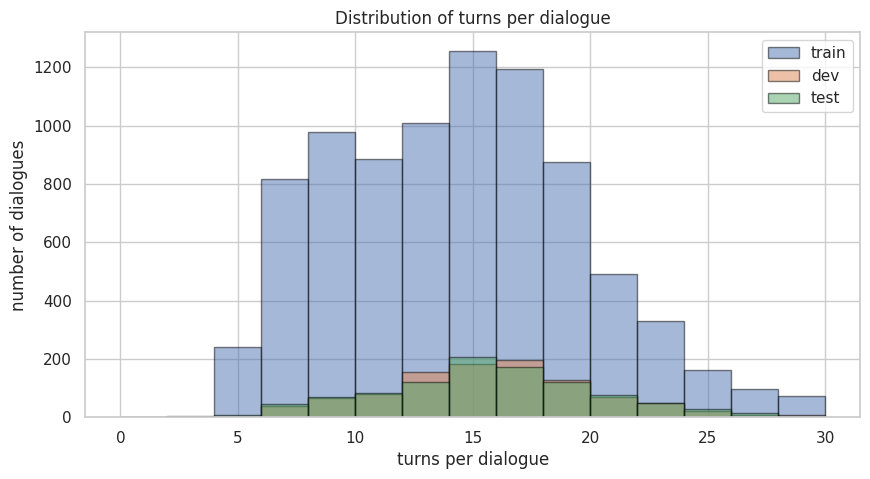

In [19]:
# Histogram of turn counts per split
plt.figure()
for split_name, counts in turn_counts.items():
  plt.hist(counts, bins=range(0, 32, 2), alpha=0.5, label=split_name, edgecolor="black")

plt.xlabel("turns per dialogue")
plt.ylabel("number of dialogues")
plt.title("Distribution of turns per dialogue")
plt.legend()
plt.savefig(FIG_DIR / "02_turns_per_dialogue.png", dpi=150, bbox_inches="tight")
plt.show()

### Utterance length

In [20]:
# Collect utterance word counts per speaker, across all splits combined
user_lengths = []
system_lengths = []

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      n_words = len(t["utterance"].split())
      if t["speaker"] == "USER":
        user_lengths.append(n_words)
      else:
        system_lengths.append(n_words)

# Summary stats
pd.DataFrame([
    {"speaker": "USER", "min": min(user_lengths), "mean": round(np.mean(user_lengths), 1), "median": int(np.median(user_lengths)), "max": max(user_lengths)},
    {"speaker": "SYSTEM", "min": min(system_lengths), "mean": round(np.mean(system_lengths), 1), "median": int(np.median(system_lengths)), "max": max(system_lengths)},
])

,speaker,min,mean,median,max
0,USER,1,11.5,11,38
1,SYSTEM,1,15.0,14,75


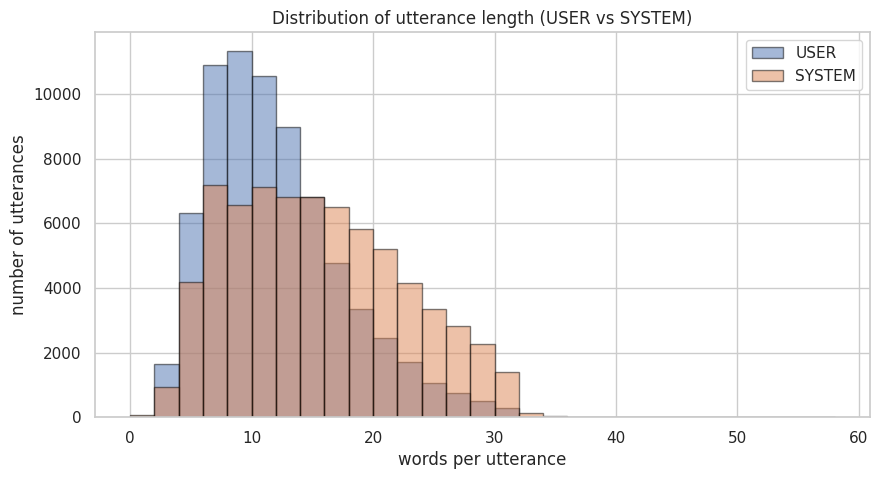

In [21]:
# Histogram of utterance length (words) for USER vs SYSTEM
plt.figure()
plt.hist(user_lengths, bins=range(0, 60, 2), alpha=0.5, label="USER", edgecolor="black")
plt.hist(system_lengths, bins=range(0, 60, 2), alpha=0.5, label="SYSTEM", edgecolor="black")

plt.xlabel("words per utterance")
plt.ylabel("number of utterances")
plt.title("Distribution of utterance length (USER vs SYSTEM)")
plt.legend()
plt.savefig(FIG_DIR / "03_utterance_length.png", dpi=150, bbox_inches="tight")
plt.show()

## Domain Analysis

### Domains at dialogue level

In [22]:
# Count how many dialogues in each split include each domain (one dialogue can involve multiple domains, so counts overlap)
domain_counts = defaultdict(Counter)

for split_name, dialogues in [("train", train), ("dev", dev), ("test", test)]:
  for d in dialogues:
    for service in d["services"]:
      domain_counts[service][split_name] += 1

df_domains = pd.DataFrame(domain_counts).fillna(0).astype(int).T
df_domains = df_domains.reindex(columns=["train", "dev", "test"])
df_domains["total"] = df_domains.sum(axis=1)
df_domains = df_domains.sort_values("total", ascending=False)
df_domains

,train,dev,test,total
restaurant,3836,447,445,4728
hotel,3369,418,395,4182
train,2963,479,489,3931
attraction,2681,405,399,3485
taxi,1463,211,198,1872
hospital,107,1,0,108
bus,6,0,0,6


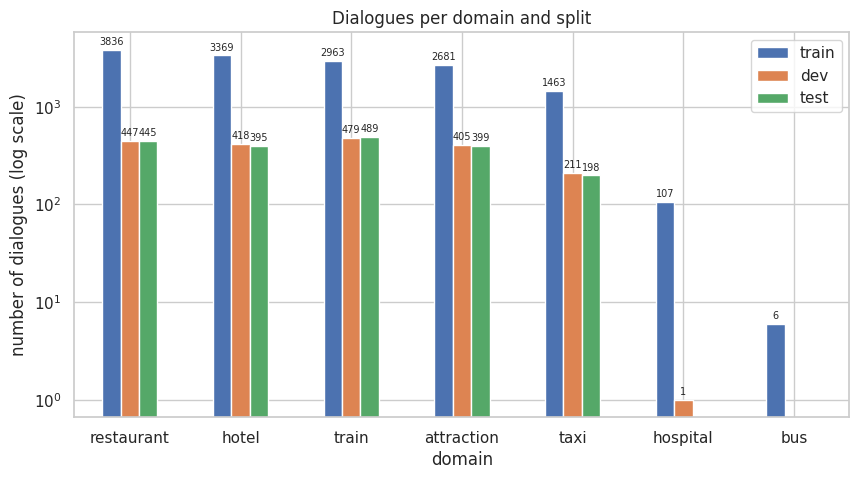

In [23]:
# Grouped bar chart of dialogue counts per domain per split (excluding the 'total' column)
ax = df_domains[["train", "dev", "test"]].plot(kind="bar", logy=True, rot=0)
plt.xlabel("domain")
plt.ylabel("number of dialogues (log scale)")
plt.title("Dialogues per domain and split")
plt.legend(loc="upper right")

# Annotate each bar with its numeric height
for container in ax.containers:
  ax.bar_label(container, padding=2, fontsize=7)

plt.savefig(FIG_DIR / "04_domains_per_split.png", dpi=150, bbox_inches="tight")
plt.show()

### Single-domain vs multi-domain dialogues

In [24]:
# For each split, count dialogues by number of domains (1 = single, 2+ = multi)
rows = []
for split_name, dialogues in [("train", train), ("dev", dev), ("test", test)]:
  by_count = Counter(len(d["services"]) for d in dialogues)
  rows.append({
      "split": split_name,
      "1 domain": by_count.get(1, 0),
      "2 domains": by_count.get(2, 0),
      "3 domains": by_count.get(3, 0),
      "4 domains": by_count.get(4, 0),
      "5 domains": by_count.get(5, 0),
  })

df_multi = pd.DataFrame(rows).set_index("split")
df_multi["total"] = df_multi.sum(axis=1)
df_multi["% multi"] = ((df_multi[["2 domains", "3 domains", "4 domains", "5 domains"]].sum(axis=1) / df_multi["total"]) * 100).round(1)
df_multi

,1 domain,2 domains,3 domains,4 domains,5 domains,total,% multi
split,,,,,,,
train,2833,3994,1168,25,0,8020,64.7
dev,209,626,160,5,0,1000,79.1
test,233,609,157,1,0,1000,76.7


### Domain co-occurrence

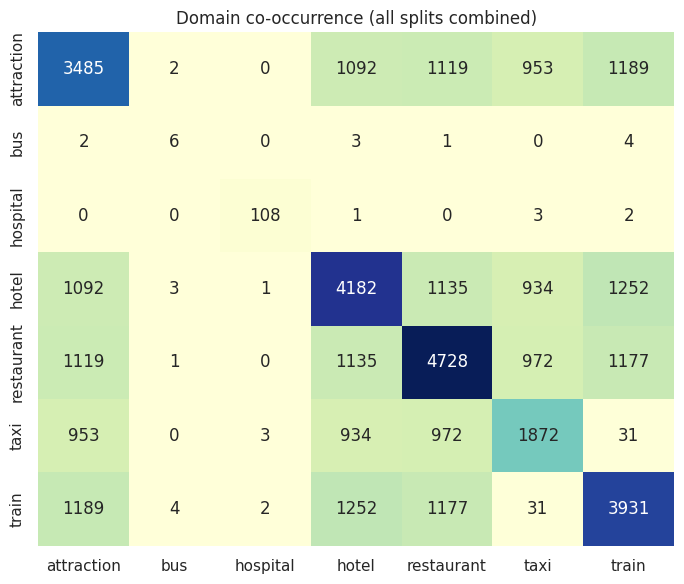

In [25]:
# Build a domain × domain matrix: count how many dialogues contain BOTH domains
all_dialogues = train + dev + test
all_domains = sorted({s for d in all_dialogues for s in d["services"]})

# Diagonal = dialogues containing that single domain. Off-diagonal = dialogues containing both
cooccur = pd.DataFrame(0, index=all_domains, columns=all_domains)
for d in all_dialogues:
  for a in d["services"]:
    cooccur.loc[a, a] += 1
  for a, b in combinations(sorted(set(d["services"])), 2):
    cooccur.loc[a, b] += 1
    cooccur.loc[b, a] += 1

plt.figure(figsize=(7, 6))
sns.heatmap(cooccur, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Domain co-occurrence (all splits combined)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_domain_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()

## Slot Ontology

### Slots per domain

In [26]:
# Collect every slot name that actually appears in any user frame across all splits
slots_per_domain = defaultdict(set)

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      for frame in t["frames"]:
        for slot_name in frame["state"]["slot_values"].keys():
          slots_per_domain[frame["service"]].add(slot_name)

rows = []
for domain in sorted(slots_per_domain.keys()):
  slots = sorted(slots_per_domain[domain])
  rows.append({
      "domain": domain,
      "num slots": len(slots),
      "slots": ", ".join(s.split("-", 1)[1] for s in slots),
  })

with pd.option_context("display.max_colwidth", None):
  display(pd.DataFrame(rows))

,domain,num slots,slots
0,attraction,3,"area, name, type"
1,bus,4,"day, departure, destination, leaveat"
2,hospital,1,department
3,hotel,10,"area, bookday, bookpeople, bookstay, internet, name, parking, pricerange, stars, type"
4,restaurant,7,"area, bookday, bookpeople, booktime, food, name, pricerange"
5,taxi,4,"arriveby, departure, destination, leaveat"
6,train,6,"arriveby, bookpeople, day, departure, destination, leaveat"


### Slot occurrence counts

In [27]:
# Count how many USER turns contain each slot (a slot counts once per turn, even if repeated)
slot_counts = Counter()

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      for frame in t["frames"]:
        for slot_name in frame["state"]["slot_values"].keys():
          slot_counts[slot_name] += 1

# Build a table sorted by frequency
df_slot_counts = pd.DataFrame(slot_counts.most_common(), columns=["slot", "num turns"])
df_slot_counts["domain"] = df_slot_counts["slot"].str.split("-", n=1).str[0]
df_slot_counts = df_slot_counts[["domain", "slot", "num turns"]]
df_slot_counts

,domain,slot,num turns
0,train,train-destination,21427
1,train,train-departure,20987
2,restaurant,restaurant-food,20963
3,train,train-day,20867
4,restaurant,restaurant-area,19548
5,restaurant,restaurant-pricerange,19201
6,restaurant,restaurant-name,16129
7,hotel,hotel-name,15803
8,hotel,hotel-area,14868
9,attraction,attraction-type,14416


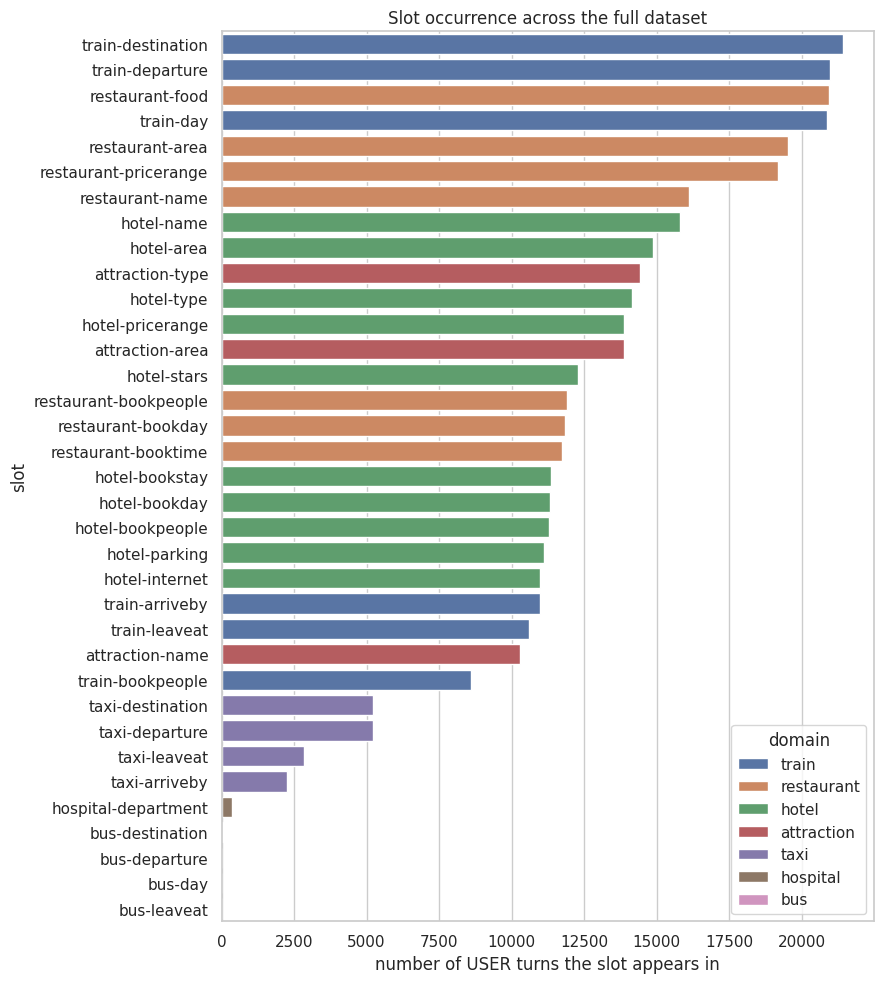

In [28]:
# Horizontal bar chart of slot occurrence, colored by domain
plt.figure(figsize=(9, 10))
sns.barplot(data=df_slot_counts, y="slot", x="num turns", hue="domain", dodge=False)
plt.xlabel("number of USER turns the slot appears in")
plt.ylabel("slot")
plt.title("Slot occurrence across the full dataset")
plt.legend(title="domain", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_slot_occurrence.png", dpi=150, bbox_inches="tight")
plt.show()

### Unique values per slot

In [29]:
# Collect all unique values per slot across the full dataset. MultiWOZ stores spelling variants as a list, we take v[0] as the canonical form
slot_values = defaultdict(set)

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      for frame in t["frames"]:
        for slot_name, values in frame["state"]["slot_values"].items():
          if values:
            slot_values[slot_name].add(values[0].lower())

# Build summary table with first 3 example values per slot
rows = []
for slot, values in slot_values.items():
  rows.append({
      "domain": slot.split("-", 1)[0],
      "slot": slot,
      "unique values": len(values),
      "examples": ", ".join(sorted(values)[:3]),
  })

df_unique = pd.DataFrame(rows).sort_values(["domain", "unique values"], ascending=[True, False]).reset_index(drop=True)

with pd.option_context("display.max_colwidth", None):
  display(df_unique)

,domain,slot,unique values,examples
0,attraction,attraction-name,198,"abbey pool, abbey pool and astroturf, abbey pool and astroturf pitch"
1,attraction,attraction-type,15,"architecture, boat, cinema"
2,attraction,attraction-area,6,"centre, dontcare, east"
3,bus,bus-destination,4,"bishops stortford, cambridge, kohinoor"
4,bus,bus-departure,1,cambridge
5,bus,bus-day,1,wednesday
6,bus,bus-leaveat,1,21:45
7,hospital,hospital-department,59,"acute medical assessment unit, acute medicine care for the elderly, acute medicine for the elderly"
8,hotel,hotel-name,132,"a & b guest house, a & b guesthouse, a and b"
9,hotel,hotel-bookday,8,"dontcare, friday, monday"


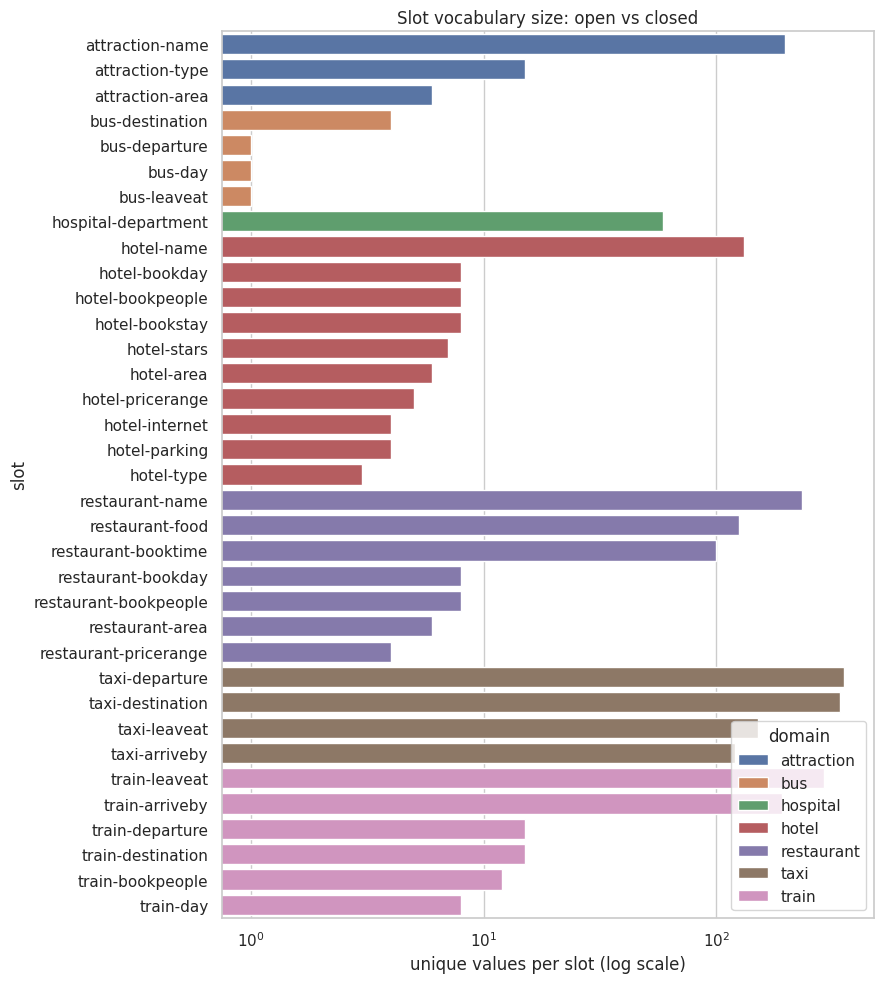

In [30]:
# Horizontal bar chart of unique-values-per-slot, colored by domain, log-scaled
plt.figure(figsize=(9, 10))
sns.barplot(data=df_unique, y="slot", x="unique values", hue="domain", dodge=False)
plt.xscale("log")
plt.xlabel("unique values per slot (log scale)")
plt.ylabel("slot")
plt.title("Slot vocabulary size: open vs closed")
plt.legend(title="domain", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_slot_vocab_size.png", dpi=150, bbox_inches="tight")
plt.show()

### `dontcare` frequency per slot

In [31]:
# For each slot, count how many USER turns set its value to "dontcare"
dontcare_counts = Counter()
total_counts = Counter()

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      for frame in t["frames"]:
        for slot_name, values in frame["state"]["slot_values"].items():
          if not values:
            continue
          total_counts[slot_name] += 1
          if values[0].lower() == "dontcare":
            dontcare_counts[slot_name] += 1

# Table of dontcare frequency per slot (only slots where it actually appears)
rows = []
for slot, n_dontcare in dontcare_counts.most_common():
  rows.append({
      "slot": slot,
      "dontcare turns": n_dontcare,
      "total turns": total_counts[slot],
      "% dontcare": round(100 * n_dontcare / total_counts[slot], 1),
  })

pd.DataFrame(rows)

,slot,dontcare turns,total turns,% dontcare
0,hotel-area,1955,14868,13.1
1,hotel-pricerange,1307,13883,9.4
2,restaurant-food,1084,20963,5.2
3,restaurant-area,1039,19548,5.3
4,restaurant-pricerange,899,19201,4.7
5,attraction-area,889,13869,6.4
6,hotel-parking,761,11124,6.8
7,hotel-internet,615,10973,5.6
8,attraction-type,543,14416,3.8
9,hotel-stars,426,12280,3.5


### Requested slots frequency

In [32]:
# For each slot, count how many USER turns include it in requested_slots
requested_counts = Counter()

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      for frame in t["frames"]:
        for slot_name in frame["state"]["requested_slots"]:
          requested_counts[slot_name] += 1

# Build a table of the top requested slots
df_requested = pd.DataFrame(requested_counts.most_common(), columns=["slot", "times requested"])
df_requested["domain"] = df_requested["slot"].str.split("-", n=1).str[0]
df_requested = df_requested[["domain", "slot", "times requested"]]
df_requested

,domain,slot,times requested
0,attraction,attraction-address,1444
1,attraction,attraction-postcode,1409
2,attraction,attraction-phone,1367
3,restaurant,restaurant-address,1349
4,restaurant,restaurant-phone,1222
5,attraction,attraction-entrancefee,1123
6,train,train-price,1011
7,train,train-ref,942
8,restaurant,restaurant-postcode,835
9,train,train-duration,779


### Ontology tree

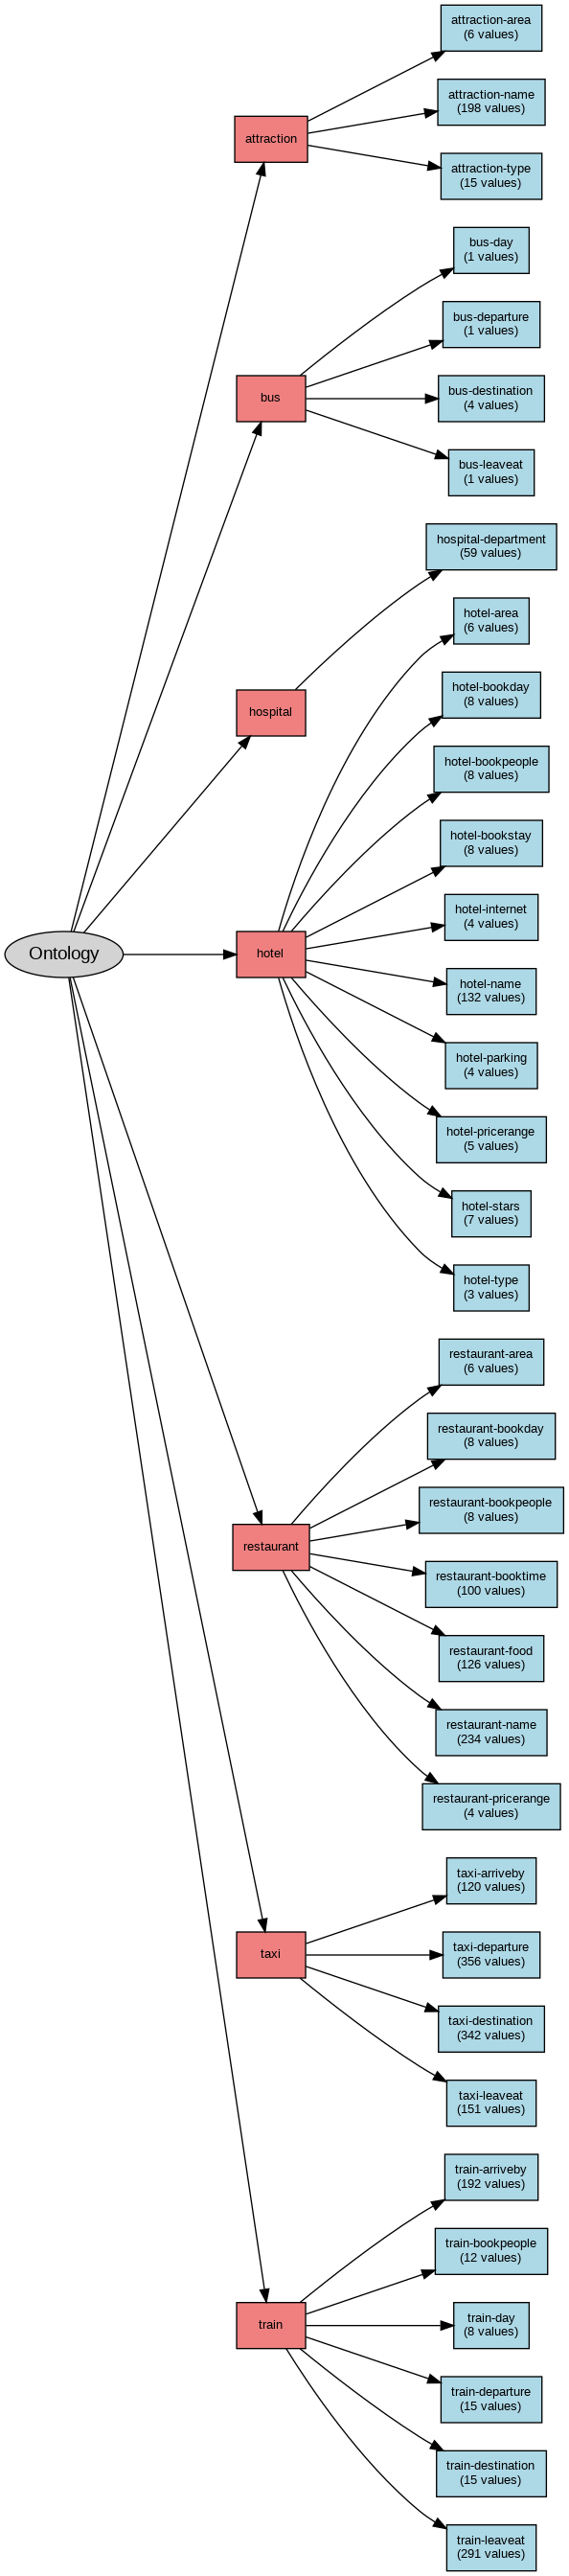

In [33]:
from graphviz import Digraph
from IPython.display import Image

# Group slots by domain using the slot_values dict we already computed
domain_slots = defaultdict(dict)
for slot_name, values in slot_values.items():
  domain = slot_name.split("-", 1)[0]
  domain_slots[domain][slot_name] = values

# Build the tree
dot = Digraph("Ontology", format="png")
dot.attr(rankdir="LR", ranksep="1.2", nodesep="0.3")
dot.attr("node", shape="box", style="filled", fillcolor="lightblue", fontname="Helvetica", fontsize="10")

dot.node("root", "Ontology", shape="ellipse", fillcolor="lightgrey", fontsize="14")

for domain, slots in sorted(domain_slots.items()):
  dom_node = f"dom_{domain}"
  dot.node(dom_node, domain, fillcolor="lightcoral")
  dot.edge("root", dom_node)
  for slot, values in sorted(slots.items()):
    dot.node(f"{dom_node}_{slot}", f"{slot}\n({len(values)} values)")
    dot.edge(dom_node, f"{dom_node}_{slot}")

# Save it
output_path = dot.render(FIG_DIR / "ontology_tree", cleanup=True)

# Display inline
Image(output_path)

## Intent & Belief State Dynamics

### Active intents

In [34]:
# Count active_intent across all USER frames in all splits. NONE = the frame's domain is not active in this turn (most frames, since each USER turn has 8 frames)
intent_counts = Counter()

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      for frame in t["frames"]:
        intent_counts[frame["state"]["active_intent"]] += 1

df_intents = pd.DataFrame(intent_counts.most_common(), columns=["intent", "count"])
df_intents["% of frames"] = (df_intents["count"] / df_intents["count"].sum() * 100).round(1)
df_intents

,intent,count,% of frames
0,NONE,502665,87.9
1,find_restaurant,13188,2.3
2,find_hotel,13004,2.3
3,find_train,12650,2.2
4,find_attraction,10566,1.8
5,book_restaurant,5534,1.0
6,book_hotel,5386,0.9
7,find_taxi,4715,0.8
8,book_train,3251,0.6
9,find_hospital,727,0.1


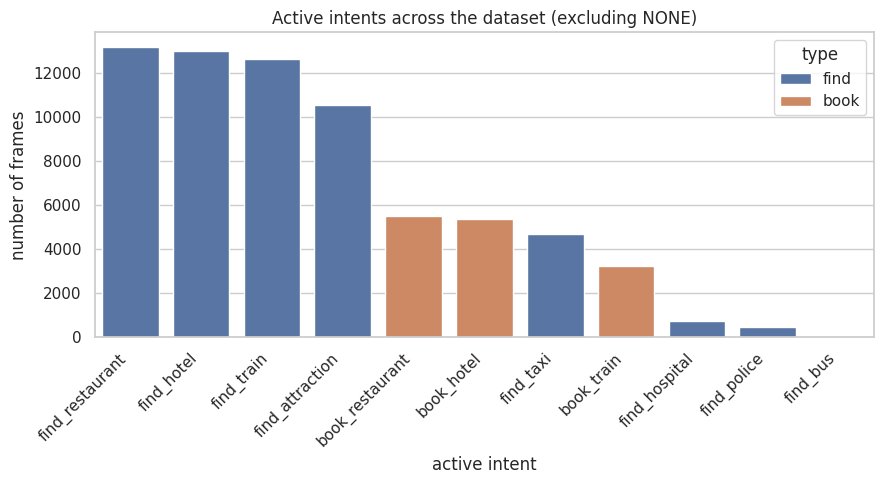

In [35]:
# Bar chart of active intents, excluding NONE
df_active = df_intents[df_intents["intent"] != "NONE"].copy()
df_active["type"] = df_active["intent"].str.split("_").str[0]

plt.figure(figsize=(9, 5))
sns.barplot(data=df_active, x="intent", y="count", hue="type", dodge=False)
plt.xticks(rotation=45, ha="right")
plt.xlabel("active intent")
plt.ylabel("number of frames")
plt.title("Active intents across the dataset (excluding NONE)")
plt.legend(title="type")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_active_intents.png", dpi=150, bbox_inches="tight")
plt.show()

### Belief state growth across turn position

In [36]:
# For each USER turn, count the total number of slot-value pairs across all active frames. Group by turn position (0, 2, 4, ... - user turns are always even-indexed)
slots_by_turn = defaultdict(list)

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      if t["speaker"] != "USER":
        continue
      n_slots = sum(len(frame["state"]["slot_values"]) for frame in t["frames"] if frame["state"]["active_intent"] != "NONE")
      slots_by_turn[int(t["turn_id"])].append(n_slots)

# Mean slots per turn position
df_growth = pd.DataFrame([
    {"turn_id": turn_id, "mean slots": round(np.mean(counts), 2), "num dialogues": len(counts)}
    for turn_id, counts in sorted(slots_by_turn.items())
])
df_growth.head(15)

,turn_id,mean slots,num dialogues
0,0,1.44,10437
1,2,2.61,10433
2,4,3.26,10181
3,6,3.27,9280
4,8,3.40,8163
5,10,3.53,7115
6,12,3.29,5831
7,14,2.99,4188
8,16,2.84,2626
9,18,2.80,1503


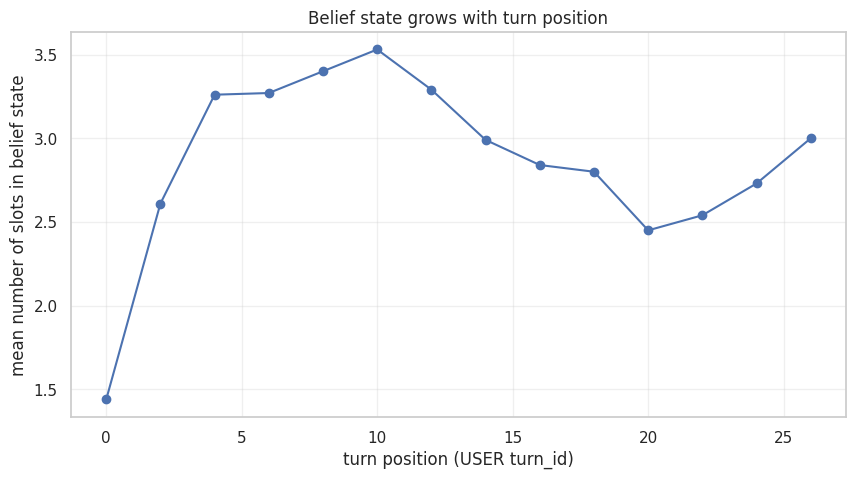

In [37]:
# Line plot: mean belief-state size vs turn position
# Restrict to turn positions where we have enough dialogues (>=100) to avoid noisy tail
df_plot = df_growth[df_growth["num dialogues"] >= 100]

plt.figure()
plt.plot(df_plot["turn_id"], df_plot["mean slots"], marker="o")
plt.xlabel("turn position (USER turn_id)")
plt.ylabel("mean number of slots in belief state")
plt.title("Belief state grows with turn position")
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "09a_belief_state_growth_simple.png", dpi=150, bbox_inches="tight")
plt.show()

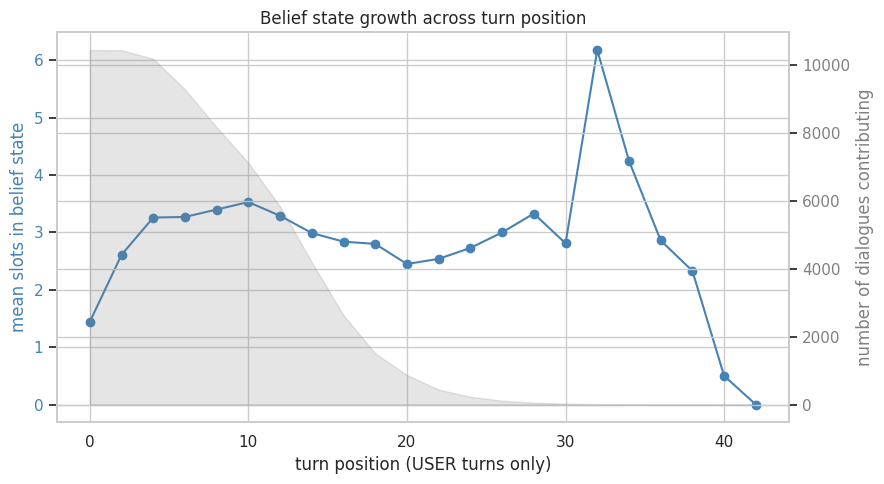

In [38]:
# Line chart: mean belief-state size across turn positions
fig, ax1 = plt.subplots(figsize=(9, 5))

# Primary axis: mean number of slots
ax1.plot(df_growth["turn_id"], df_growth["mean slots"], marker="o", color="steelblue", label="mean slots")
ax1.set_xlabel("turn position (USER turns only)")
ax1.set_ylabel("mean slots in belief state", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Secondary axis: how many dialogues contribute at each turn position
ax2 = ax1.twinx()
ax2.fill_between(df_growth["turn_id"], df_growth["num dialogues"], alpha=0.2, color="gray", label="dialogues at this turn")
ax2.set_ylabel("number of dialogues contributing", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

plt.title("Belief state growth across turn position")
fig.tight_layout()
plt.savefig(FIG_DIR / "09b_belief_state_growth_dual.png", dpi=150, bbox_inches="tight")
plt.show()

The belief state grows quickly in the first few turns (from ~1 slot at turn 0 to ~3.5 slots by turn 10), then stays roughly flat. The gray area shows how many dialogues are still going at each turn and it drops fast after turn 10, so the numbers to the right are based on very few dialogues and should not be trusted (the spike near turn 32 is noise from a handful of very long outliers, not a real pattern).

### Booking intent frequency

In [39]:
# For each dialogue, check whether any USER frame ever has a book_* intent
rows = []
for split_name, dialogues in [("train", train), ("dev", dev), ("test", test)]:
  n_total = len(dialogues)
  n_with_booking = 0

  for d in dialogues:
    has_booking = any(frame["state"]["active_intent"].startswith("book_") for t in d["turns"] if t["speaker"] == "USER" for frame in t["frames"])
    if has_booking:
      n_with_booking += 1

  rows.append({
      "split": split_name,
      "dialogues": n_total,
      "with booking": n_with_booking,
      "% with booking": round(100 * n_with_booking / n_total, 1),
  })

pd.DataFrame(rows)

,split,dialogues,with booking,% with booking
0,train,8437,4858,57.6
1,dev,1000,694,69.4
2,test,1000,688,68.8


## Dialog Acts

### Dialog act frequency

In [40]:
# Count how often each dialog act appears, separately for USER and SYSTEM turns
user_acts = Counter()
system_acts = Counter()

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      target = user_acts if t["speaker"] == "USER" else system_acts
      for act_name in t["dialog_act"].keys():
        target[act_name] += 1

print(f"Distinct USER acts: {len(user_acts)}")
print(f"Distinct SYSTEM acts: {len(system_acts)}")
print(f"Total distinct acts: {len(set(user_acts) | set(system_acts))}")

Distinct USER acts: 17
Distinct SYSTEM acts: 35
Total distinct acts: 36


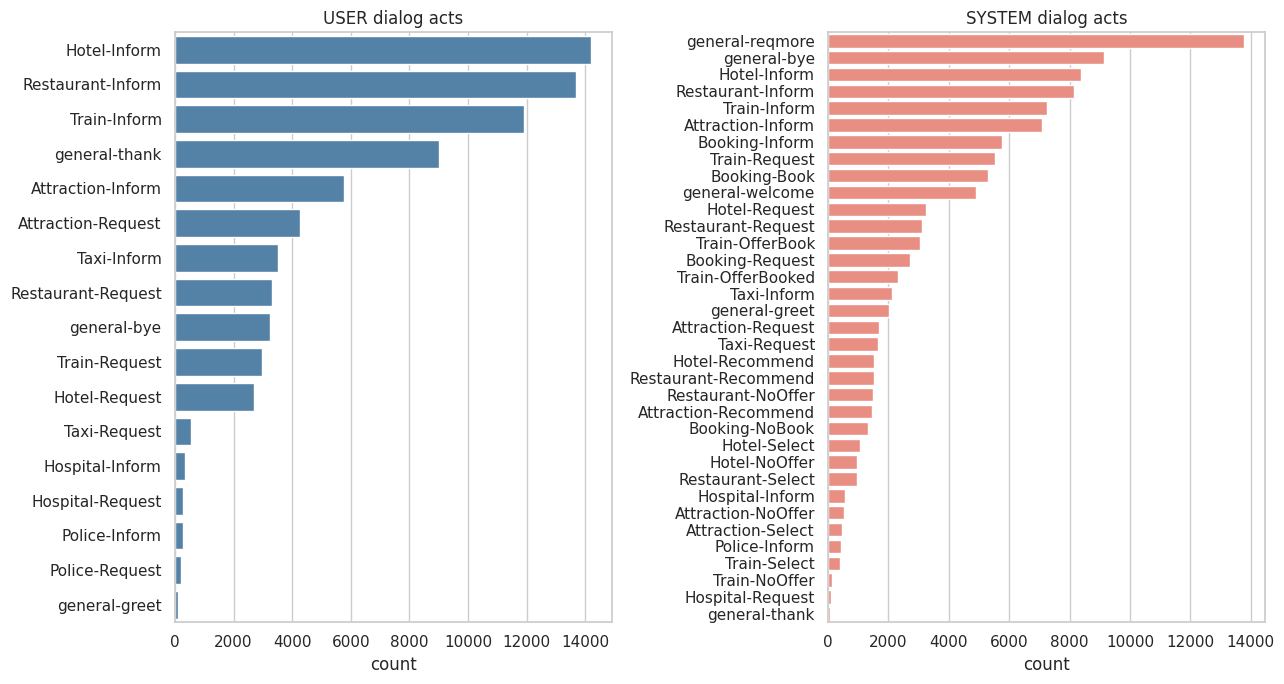

In [41]:
# Side-by-side bar charts: top USER acts vs top SYSTEM acts
df_user_acts = pd.DataFrame(user_acts.most_common(), columns=["act", "count"])
df_system_acts = pd.DataFrame(system_acts.most_common(), columns=["act", "count"])

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

sns.barplot(data=df_user_acts, y="act", x="count", ax=axes[0], color="steelblue")
axes[0].set_title("USER dialog acts")
axes[0].set_xlabel("count")
axes[0].set_ylabel("")

sns.barplot(data=df_system_acts, y="act", x="count", ax=axes[1], color="salmon")
axes[1].set_title("SYSTEM dialog acts")
axes[1].set_xlabel("count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "10_dialog_acts.png", dpi=150, bbox_inches="tight")
plt.show()

### Acts per turn

In [42]:
# For each turn, count how many distinct dialog acts it carries. Split by speaker
user_acts_per_turn = []
system_acts_per_turn = []

for dialogues in [train, dev, test]:
  for d in dialogues:
    for t in d["turns"]:
      n = len(t["dialog_act"])
      if t["speaker"] == "USER":
        user_acts_per_turn.append(n)
      else:
        system_acts_per_turn.append(n)

# Summary table
pd.DataFrame([
    {"speaker": "USER", "min": min(user_acts_per_turn), "mean": round(np.mean(user_acts_per_turn), 2), "median": int(np.median(user_acts_per_turn)), "max": max(user_acts_per_turn), "% multi-act": round(100 * sum(1 for x in user_acts_per_turn if x > 1) / len(user_acts_per_turn), 1)},
    {"speaker": "SYSTEM", "min": min(system_acts_per_turn), "mean": round(np.mean(system_acts_per_turn), 2), "median": int(np.median(system_acts_per_turn)), "max": max(system_acts_per_turn), "% multi-act": round(100 * sum(1 for x in system_acts_per_turn if x > 1) / len(system_acts_per_turn), 1)},
])

,speaker,min,mean,median,max,% multi-act
0,USER,0,1.07,1,6,7.9
1,SYSTEM,0,1.54,2,5,50.4


## Database

### DB sizes and sample entry

In [43]:
# Load every domain DB that exists in the repo and report its size
domains = ["hotel", "restaurant", "attraction", "train", "taxi", "hospital", "police", "bus"]
dbs = {}

for domain in domains:
  db_file = DB_DIR / f"{domain}_db.json"
  if not db_file.exists():
    print(f"{domain}: no DB file")
    continue
  with open(db_file, "r", encoding="utf-8") as f:
    dbs[domain] = json.load(f)

# Summary table
rows = []
for domain, entries in dbs.items():
  rows.append({
      "domain": domain,
      "entries": len(entries) if isinstance(entries, list) else "not a list",
      "sample keys": list(entries[0].keys()) if isinstance(entries, list) and entries else [],
  })

with pd.option_context("display.max_colwidth", None):
  display(pd.DataFrame(rows))

,domain,entries,sample keys
0,hotel,33,"[address, area, internet, parking, id, location, name, phone, postcode, price, pricerange, stars, takesbookings, type]"
1,restaurant,110,"[address, area, food, id, introduction, location, name, phone, postcode, pricerange, type]"
2,attraction,79,"[address, area, entrance fee, id, location, name, openhours, phone, postcode, pricerange, type]"
3,train,2828,"[arriveBy, day, departure, destination, duration, leaveAt, price, trainID]"
4,taxi,1,"[taxi_colors, taxi_types, taxi_phone]"
5,hospital,66,"[department, id, phone]"
6,police,1,"[name, address, id, phone]"
7,bus,2828,"[arriveBy, day, departure, destination, duration, leaveAt, price, trainID]"


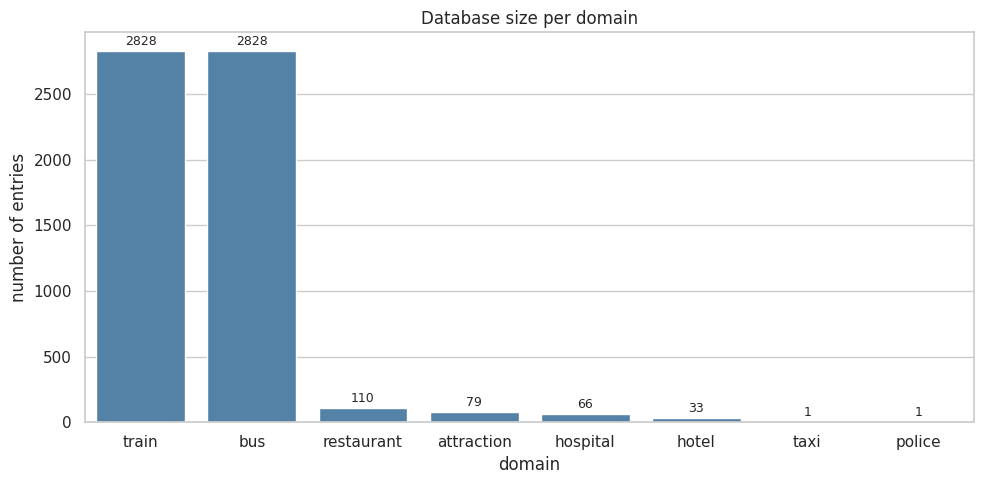

In [44]:
# Bar chart of DB sizes per domain (excluding taxi which has no fixed DB)
db_sizes = {
    domain: len(entries)
    for domain, entries in dbs.items()
    if isinstance(entries, list)
}

df_db = pd.DataFrame(sorted(db_sizes.items(), key=lambda kv: kv[1], reverse=True), columns=["domain", "entries"])

ax = sns.barplot(data=df_db, x="domain", y="entries", color="steelblue")
plt.ylabel("number of entries")
plt.title("Database size per domain")

# Annotate bars with counts
for container in ax.containers:
  ax.bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "11_db_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

### Attribute comparison across domains

In [45]:
# Build a domain × attribute presence matrix (checkmark if the attribute exists in that DB)
domain_attrs = {
    domain: set(entries[0].keys())
    for domain, entries in dbs.items()
    if isinstance(entries, list) and entries
}

all_attrs = sorted({a for attrs in domain_attrs.values() for a in attrs})

df_attrs = pd.DataFrame({domain: [("✓" if a in attrs else "") for a in all_attrs] for domain, attrs in domain_attrs.items()}, index=all_attrs)

with pd.option_context("display.max_rows", None):
  display(df_attrs)

,hotel,restaurant,attraction,train,taxi,hospital,police,bus
address,✓,✓,✓,,,,✓,
area,✓,✓,✓,,,,,
arriveBy,,,,✓,,,,✓
day,,,,✓,,,,✓
department,,,,,,✓,,
departure,,,,✓,,,,✓
destination,,,,✓,,,,✓
duration,,,,✓,,,,✓
entrance fee,,,✓,,,,,
food,,✓,,,,,,


## Summary

### Key numbers at a glance

In [46]:
# Pull the headline numbers from each section into one summary table
all_dialogues = train + dev + test
all_turns = [t for d in all_dialogues for t in d["turns"]]
all_user_turns = [t for t in all_turns if t["speaker"] == "USER"]

# Multi-domain fraction
n_multi = sum(1 for d in all_dialogues if len(d["services"]) > 1)

# Fraction of user frames with an active intent
n_active_intent_frames = sum(1 for t in all_user_turns for f in t["frames"] if f["state"]["active_intent"] != "NONE")
n_total_user_frames = sum(len(t["frames"]) for t in all_user_turns)

# Multi-act fraction
n_multiact_turns = sum(1 for t in all_turns if len(t["dialog_act"]) > 1)
n_annotated_turns = sum(1 for t in all_turns if t["dialog_act"])

summary = {
    "dialogues (total)": len(all_dialogues),
    "turns (total)": len(all_turns),
    "avg turns / dialogue": round(len(all_turns) / len(all_dialogues), 1),
    "domains": len({s for d in all_dialogues for s in d["services"]}),
    "% multi-domain dialogues": round(100 * n_multi / len(all_dialogues), 1),
    "distinct slots": sum(len(s) for s in slots_per_domain.values()),
    "distinct dialog acts": len(set(user_acts) | set(system_acts)),
    "% active user frames": round(100 * n_active_intent_frames / n_total_user_frames, 1),
    "% multi-act turns (of annotated)": round(100 * n_multiact_turns / n_annotated_turns, 1),
    "% dialogues with booking": round(100 * sum(
        any(f["state"]["active_intent"].startswith("book_") for t in d["turns"] if t["speaker"] == "USER" for f in t["frames"])
        for d in all_dialogues
    ) / len(all_dialogues), 1),
}

pd.DataFrame(summary.items(), columns=["metric", "value"])

,metric,value
0,dialogues (total),10437.0
1,turns (total),143044.0
2,avg turns / dialogue,13.7
3,domains,7.0
4,% multi-domain dialogues,64.6
5,distinct slots,35.0
6,distinct dialog acts,36.0
7,% active user frames,12.1
8,% multi-act turns (of annotated),29.4
9,% dialogues with booking,59.8


### Download all figures as PNGs

In [47]:
for i, fig in enumerate(saved_figures, start=1):
  title = fig.axes[0].get_title() if fig.axes else f"figure_{i}"
  safe = "".join(c if c.isalnum() or c in "-_ " else "_" for c in title).strip().replace(" ", "_")[:60]
  filename = f"{i:02d}_{safe or 'figure'}.png"
  fig.savefig(FIG_DIR / filename, dpi=150, bbox_inches="tight")
  print(f"Saved {filename}")

In [48]:
# Zip everything
shutil.make_archive("/content/mwz22_figures", "zip", FIG_DIR)

print(f"Contents of {FIG_DIR}:")
for f in sorted(FIG_DIR.glob("*.png")):
  print(f" {f.name}")

Contents of /content/figures:
 01_split_sizes.png
 02_turns_per_dialogue.png
 03_utterance_length.png
 04_domains_per_split.png
 05_domain_cooccurrence.png
 06_slot_occurrence.png
 07_slot_vocab_size.png
 08_active_intents.png
 09a_belief_state_growth_simple.png
 09b_belief_state_growth_dual.png
 10_dialog_acts.png
 11_db_sizes.png
 ontology_tree.png


In [ ]:
# Dowload the zip file
# from google.colab import files
# files.download("/content/mwz22_full_eda_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>